In [ ]:
# 📊 Customer Churn Analysis using SQL and Python

### End-to-End Data Analysis Project

**Author:** Sakshi Naik

**Tools Used**
- MySQL
- SQL
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

---

In [ ]:
# 📑 Table of Contents

1. Business Problem
2. Project Objectives
3. Project Workflow
4. Dataset Overview
5. Import Libraries
6. Load Dataset
7. Data Exploration
8. Exploratory Data Analysis
9. Business Questions
   - Q1 Monthly Charges vs Churn
   - Q2 Contract Type vs Churn
   - Q3 Tenure vs Churn
   - Q4 Total Services vs Churn
   - Q5 Payment Method vs Churn
   - Q6 Contract Type + Payment Method
10. Key Business Insights
11. Business Recommendations
12. Conclusion

In [ ]:
# 🎯 Business Problem

Customer churn is one of the biggest challenges faced by telecommunication companies. Acquiring a new customer is significantly more expensive 
than retaining an existing one. Therefore, understanding the reasons behind customer churn is essential for improving customer retention and 
increasing long-term business revenue.

The objective of this project is to analyze customer behavior, identify the key factors influencing churn, and provide data-driven business 
recommendations using SQL and Python.

In [ ]:
# 📌 Project Objectives

The primary objectives of this project are:

- Understand the customer churn dataset.
- Perform exploratory data analysis (EDA).
- Identify the major factors contributing to customer churn.
- Answer key business questions using SQL and Python.
- Generate actionable business insights.
- Provide recommendations to improve customer retention.

In [ ]:
# 🔄 Project Workflow

Business Problem

↓

Data Collection

↓

SQL Analysis

↓

Python Data Cleaning

↓

Exploratory Data Analysis (EDA)

↓

Business Insights

↓

Business Recommendations

In [ ]:
# 📂 Dataset Overview

The dataset contains customer information collected from a telecommunication company.

It includes customer demographics, subscribed services, billing information, contract details, payment methods, tenure, and customer churn status.

Dataset Summary:

- Total Records: 7032
- Total Features: 21
- Target Variable: Churn

In [ ]:
# 📚 Import Required Libraries

The following libraries are used for data manipulation, visualization, and database connectivity throughout the project.

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Database Connectivity
import mysql.connector

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
plt.style.use("ggplot")

# Display graphs inside Jupyter Notebook
%matplotlib inline

In [10]:
# 📥 Load Dataset from MySQL

The customer dataset is stored in a MySQL database. The following code establishes a connection with the database and loads the data 
into a Pandas DataFrame for further analysis.

import mysql.connector

print("MySQL Connector Imported Successfully!")


MySQL Connector Imported Successfully!


In [11]:
import mysql.connector

mydb = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="churn_analysis"
)

print("Connected Successfully!")

Connected Successfully!


In [71]:
import pandas as pd
import mysql.connector

mydb = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="churn_analysis"
)

query = "SELECT * FROM customers"

df = pd.read_sql(query, mydb)

### Preview of Dataset
Displaying the first five records helps us understand the structure of the dataset and verify that the data has been loaded correctly.


df.head()

C:\Users\ATHARVA\AppData\Local\Temp\ipykernel_13080\2175007691.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, mydb)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# 🔍 Initial Data Exploration

Before performing any analysis, it is important to understand the structure of the dataset.

This section explores:

- Dataset dimensions
- Sample records
- Data types
- Summary statistics
- Missing values

In [13]:
### Dataset Information

This section provides information about data types, non-null values, and memory usage.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [14]:
type(df)

pandas.core.frame.DataFrame

In [17]:
### Dataset Shape

The shape of the dataset provides the total number of observations (rows) and features (columns).

df.shape

(7032, 21)

In [23]:
### Statistical Summary

A statistical summary helps understand the distribution of numerical features by displaying count, mean, standard deviation, 
minimum, maximum, and quartiles.

df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [20]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [25]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [27]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [ ]:
# 📈 Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps uncover patterns, trends, and relationships within the data before drawing business conclusions.

This section focuses on understanding customer behavior using statistical summaries and visualizations.

In [ ]:
## Customer Churn Distribution

### Objective

To understand the distribution of the target variable (Churn) and identify whether the dataset is balanced or imbalanced before 
performing further analysis.

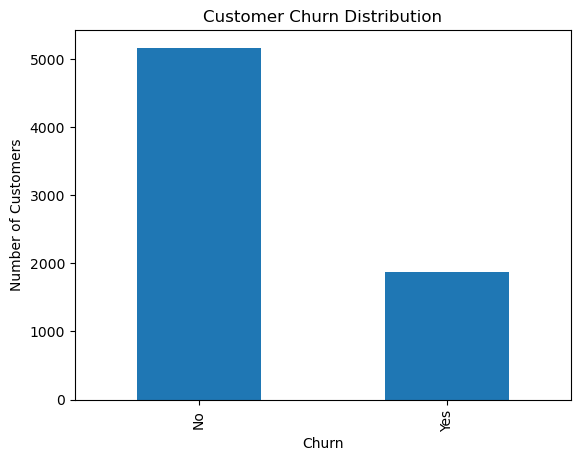

In [30]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
### Observation

- The majority of customers did not churn.
- Approximately 73.4% of customers remained with the company, while 26.6% of customers churned.
- The dataset is moderately imbalanced.

### Business Insight

The company retains most of its customers; however, nearly one-fourth of the customer base has churned, representing a significant business concern. 
    Understanding the factors influencing customer churn is essential for improving customer retention and reducing revenue loss.

### Conclusion

The target variable is moderately imbalanced, which should be considered during future predictive modeling. This analysis provides a foundation
for investigating the key drivers of customer churn.

In [ ]:
------
# 📌 Business Question 1
------
## Does Higher Monthly Charges Increase Customer Churn?

### Objective

To determine whether customers paying higher monthly charges are more likely to churn than customers paying lower monthly charges.

In [56]:
# Average Monthly Charges by Churn Status

monthly_charge_analysis = df.groupby("Churn").agg(
    Average_Monthly_Charge=("MonthlyCharges", "mean"),
    Total_Customers=("Churn", "count")
)

monthly_charge_analysis

,Average_Monthly_Charge,Total_Customers
Churn,,
No,61.307408,5163
Yes,74.441332,1869


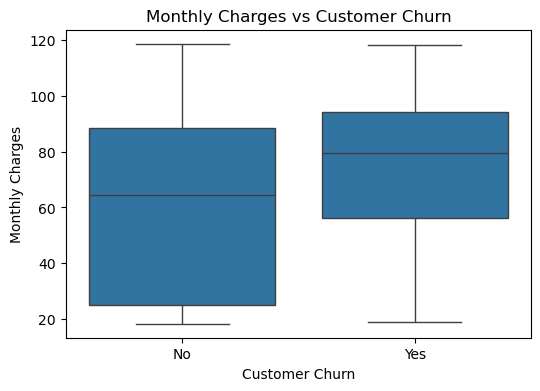

In [57]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [ ]:
### 🔍 Key Findings

- Customers who churn have a higher average monthly charge than customers who remain with the company.
- The median monthly charge is also higher for churned customers.
- The distribution indicates that customers paying higher monthly charges are more likely to churn.

### 💼 Business Interpretation

Customers paying higher monthly charges appear to have a greater tendency to leave the company. While higher charges are associated with 
increased churn, this relationship does not necessarily imply causation. Other factors, such as contract type, premium services, or competitor pricing,
may also contribute to customer churn.

### ✅ Business Recommendation

- Review pricing strategies for premium plans.
- Introduce loyalty discounts for high-paying customers.
- Offer bundled services to increase perceived value.
- Identify high-paying customers who are at risk and target them with personalized retention campaigns.

In [ ]:
-----
## 📌 Business Question 2
-----
### Does Contract Type Influence Customer Churn?

### Objective

To analyze the relationship between different contract types and customer churn in order to identify which contract plans are associated 
with higher customer retention and which are associated with greater customer attrition.

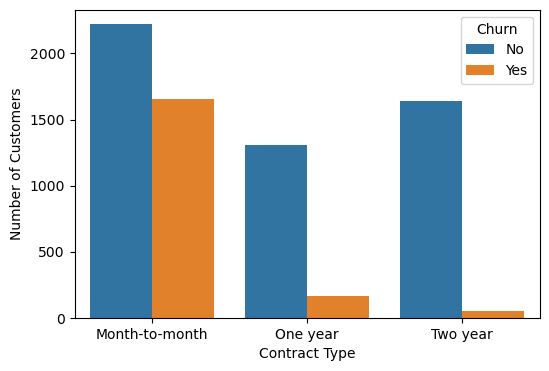

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(data=df , x="Contract", hue="Churn")

plt.title=("Contract type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
### 🔍 Key Findings

- Customers with **Month-to-Month** contracts have the highest number of churned customers.
- Customers with **One-Year** contracts experience significantly lower churn than Month-to-Month contracts.
- Customers with **Two-Year** contracts have the lowest number of churned customers and the highest customer retention.

### 💼 Business Interpretation

The visualization clearly indicates that contract duration plays an important role in customer retention. Customers enrolled in long-term contracts 
are much less likely to leave the company, whereas customers with Month-to-Month contracts are considerably more likely to churn.

A longer contract increases customer commitment and reduces the likelihood of switching to competitors.

### ✅ Recommendation

- Encourage customers to upgrade from Month-to-Month contracts to One-Year or Two-Year plans.
- Introduce loyalty rewards, discounts, or bundled offers for customers choosing long-term contracts.
- Focus customer retention campaigns primarily on Month-to-Month customers, as they represent the highest-risk segment.

In [ ]:
-----
# 📌 Business Question 3
-----
## Does Customer Tenure Influence Churn?

### Objective

To analyze whether customers who have been associated with the company for a longer period are less likely to churn compared to newer customers.

In [58]:
# Average Tenure by Churn Status

tenure_analysis = df.groupby("Churn").agg(
    Average_Tenure=("tenure", "mean"),
    Minimum_Tenure=("tenure", "min"),
    Maximum_Tenure=("tenure", "max"),
    Total_Customers=("Churn", "count")
)

tenure_analysis

,Average_Tenure,Minimum_Tenure,Maximum_Tenure,Total_Customers
Churn,,,,
No,37.650010,1,72,5163
Yes,17.979133,1,72,1869


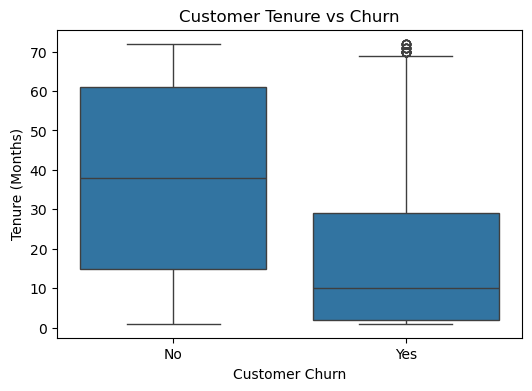

In [59]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Tenure (Months)")

plt.show()

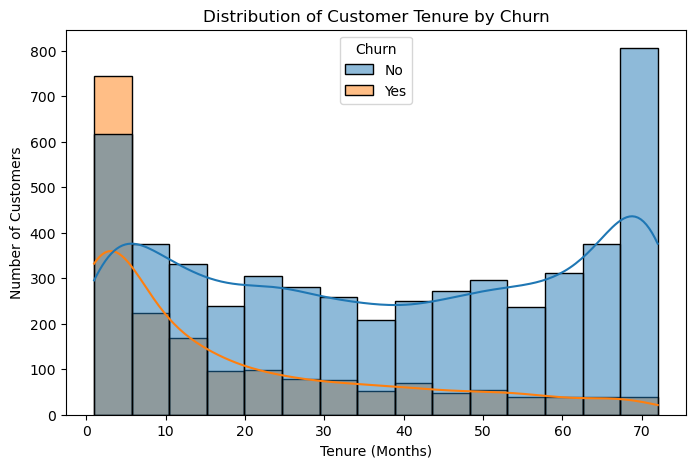

In [60]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="tenure", hue="Churn", kde=True)

plt.title("Distribution of Customer Tenure by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
### 🔍 Key Findings

- Customers who churn have a significantly lower average tenure than customers who remain with the company.
- Long-term customers are considerably less likely to churn.
- The median tenure is much higher for customers who stay with the company.

### 💼 Business Interpretation

Customer tenure has a strong relationship with customer retention. New customers are more likely to leave the company during the early months of 
their subscription, whereas customers who remain with the company for a longer period tend to become more loyal.

### ✅ Business Recommendation

- Focus customer retention efforts on new customers during their initial months.
- Strengthen the onboarding experience to improve customer satisfaction.
- Offer loyalty rewards and personalized engagement programs to encourage long-term customer relationships.

In [ ]:
-----
# 📌 Business Question 4
-----
## Does Using More Services Reduce Customer Churn?

### Objective

To investigate whether customers subscribing to multiple value-added services are less likely to churn compared to customers using fewer services.

In [61]:
# Create Total_Services feature

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["Total_Services"] = (df[service_columns] == "Yes").sum(axis=1)

df[["customerID", "Total_Services"]].head()

,customerID,Total_Services
0,7590-VHVEG,1
1,5575-GNVDE,2
2,3668-QPYBK,2
3,7795-CFOCW,3
4,9237-HQITU,0


In [62]:
# Churn percentage by Total Services

service_analysis = pd.crosstab(
    df["Total_Services"],
    df["Churn"],
    normalize="index"
) * 100

service_analysis.round(2)

Churn,No,Yes
Total_Services,,
0,78.54,21.46
1,54.24,45.76
2,64.18,35.82
3,72.61,27.39
4,77.65,22.35
5,87.52,12.48
6,94.72,5.28


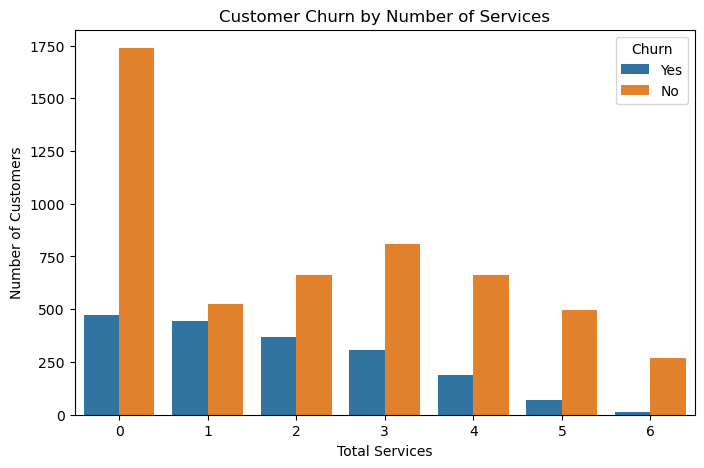

In [63]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Total_Services", hue="Churn")

plt.title("Customer Churn by Number of Services")
plt.xlabel("Total Services")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
### 🔍 Key Findings

- Customers using fewer services show a higher proportion of churn.
- Customers with multiple subscribed services are more likely to remain with the company.
- Customer retention generally improves as the number of subscribed services increases.

### 💼 Business Interpretation

Customers who subscribe to multiple services become more engaged with the company's ecosystem. Switching to another provider becomes more difficult
because multiple services would need to be replaced, increasing the switching cost and reducing the likelihood of churn.

### ✅ Business Recommendation

- Promote bundled service packages to encourage customers to adopt additional services.
- Cross-sell value-added services to existing customers.
- Design loyalty programs that reward customers for subscribing to multiple services.

In [ ]:
-----
# 📌 Business Question 5
-----
## Which Payment Method Has the Highest Customer Churn?

### Objective

To analyze customer churn across different payment methods and identify which payment options are associated with higher customer attrition. 
    This analysis helps the business understand whether payment behavior influences customer retention.

In [64]:
payment_analysis = df.groupby("PaymentMethod").agg(
    Total_Customers=("Churn", "count"),
    Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
)

payment_analysis["Churn_Rate"] = (
    payment_analysis["Churned_Customers"]
    / payment_analysis["Total_Customers"]
) * 100

payment_analysis.round(2).sort_values(
    by="Churn_Rate",
    ascending=False
)

,Total_Customers,Churned_Customers,Churn_Rate
PaymentMethod,,,
Electronic check,2365,1071,45.29
Mailed check,1604,308,19.20
Bank transfer (automatic),1542,258,16.73
Credit card (automatic),1521,232,15.25


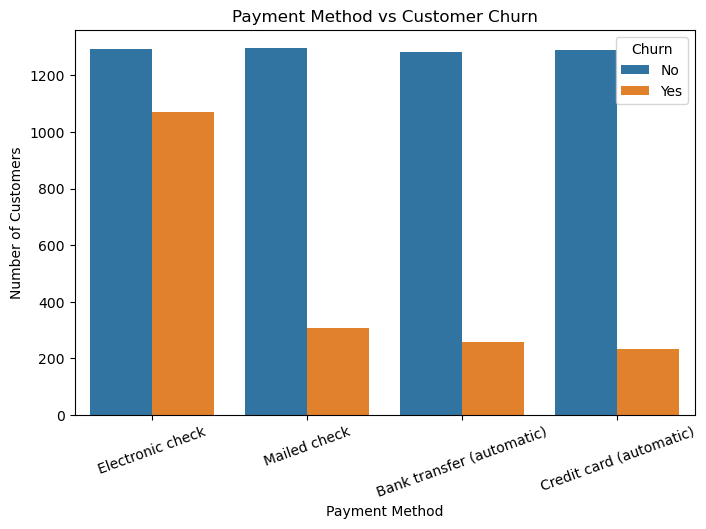

In [65]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

In [ ]:
### 🔍 Key Findings

- Customers using **Electronic Check** have the highest churn rate.
- Customers using **Credit Card (Automatic)** and **Bank Transfer (Automatic)** exhibit the lowest churn rates.
- Customers using **automatic payment methods** generally show better customer retention than those making manual payments.

### 💼 Business Interpretation

Electronic Check requires customers to manually complete payments on a regular basis. Frequent manual interactions may increase customer awareness 
of recurring expenses and make it easier for them to discontinue the service. In contrast, automatic payment methods provide a smoother billing 
experience, reducing customer effort and improving retention.

### ✅ Business Recommendation

- Encourage customers to switch from Electronic Check to automatic payment methods through incentives or promotional offers.
- Simplify the enrollment process for automatic payments.
- Target Electronic Check users with personalized retention campaigns, as they represent a high-risk customer segment.

In [ ]:
-----
# 📌 Business Question 6
-----
## How Do Contract Type and Payment Method Together Influence Customer Churn?

### Objective

To perform a multi-dimensional analysis by examining the combined effect of contract type and payment method on customer churn. 
    This analysis helps identify high-risk customer segments and supports the development of targeted customer retention strategies.

In [66]:
contract_payment_analysis = df.groupby(
    ["Contract", "PaymentMethod"]
).agg(
    Total_Customers=("Churn", "count"),
    Churned_Customers=("Churn", lambda x: (x == "Yes").sum())
)

contract_payment_analysis["Churn_Rate"] = (
    contract_payment_analysis["Churned_Customers"]
    / contract_payment_analysis["Total_Customers"]
) * 100

contract_payment_analysis = contract_payment_analysis.round(2)

contract_payment_analysis.sort_values(
    by="Churn_Rate",
    ascending=False
)

Total_Customers  Churned_Customers  \
Contract       PaymentMethod                                                   
Month-to-month Electronic check                      1850                994   
               Bank transfer (automatic)              589                201   
               Credit card (automatic)                543                178   
               Mailed check                           893                282   
One year       Electronic check                       347                 64   
               Credit card (automatic)                398                 41   
               Bank transfer (automatic)              391                 38   
Two year       Electronic check                       168                 13   
One year       Mailed check                           336                 23   
Two year       Bank transfer (automatic)              562                 19   
               Credit card (automatic)                580                 13   
               Mailed check                           375                  3   

                                          Churn_Rate  
Contract       PaymentMethod                          
Month-to-month Electronic check                53.73  
               Bank transfer (automatic)       34.13  
               Credit card (automatic)         32.78  
               Mailed check                    31.58  
One year       Electronic check                18.44  
               Credit card (automatic)         10.30  
               Bank transfer (automatic)        9.72  
Two year       Electronic check                 7.74  
One year       Mailed check                     6.85  
Two year       Bank transfer (automatic)        3.38  
               Credit card (automatic)          2.24  
               Mailed check                     0.80

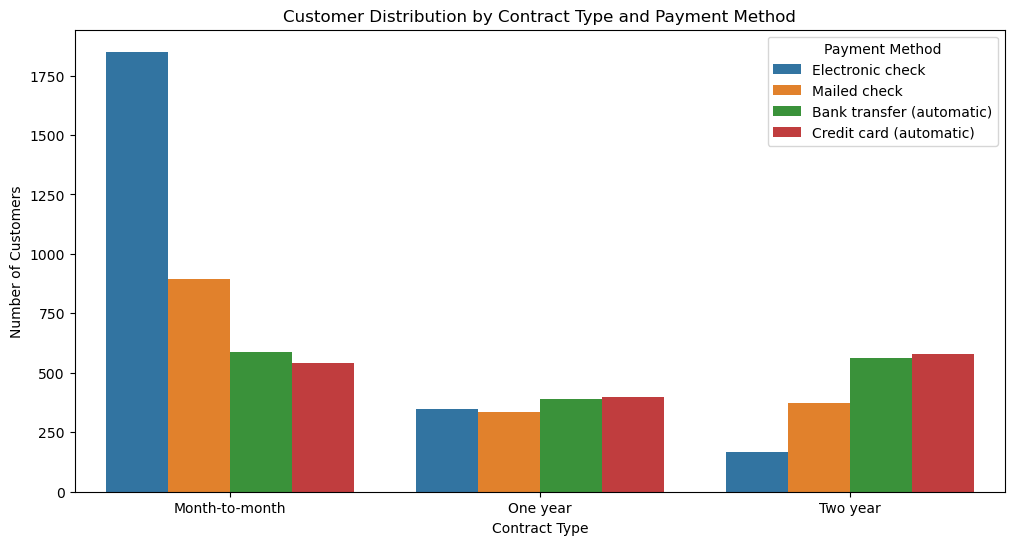

In [67]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Contract",
    hue="PaymentMethod"
)

plt.title("Customer Distribution by Contract Type and Payment Method")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.legend(title="Payment Method")

plt.show()

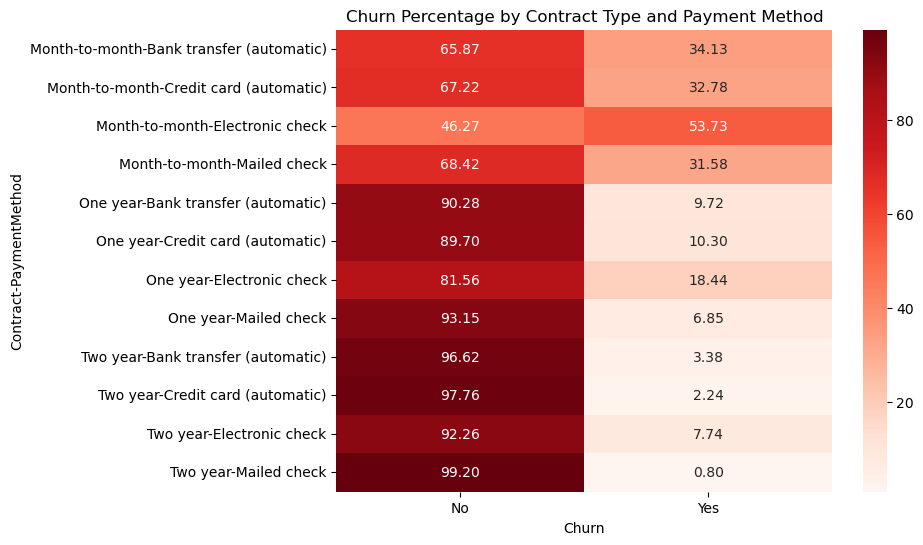

In [68]:
churn_heatmap = pd.crosstab(
    [df["Contract"], df["PaymentMethod"]],
    df["Churn"],
    normalize="index"
) * 100

churn_heatmap = churn_heatmap.round(2)

plt.figure(figsize=(8,6))

sns.heatmap(
    churn_heatmap,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Churn Percentage by Contract Type and Payment Method")

plt.show()

In [ ]:
### 🔍 Key Findings

- Customers using **Month-to-Month contracts with Electronic Check** exhibit the highest churn rate.
- Customers with **One-Year** and **Two-Year** contracts show considerably lower churn across all payment methods.
- Customers using **automatic payment methods** generally have lower churn compared to those using Electronic Check.
- The combination of **contract type** and **payment method** provides a stronger understanding of customer churn than analyzing either feature independently.

### 💼 Business Interpretation

Customer churn is influenced by the interaction of multiple factors rather than a single variable. Month-to-Month customers using Electronic Check represent the highest-risk customer segment. Long-term contracts combined with automatic payment methods are associated with significantly better customer retention.

### ✅ Business Recommendation

- Prioritize retention campaigns for customers using Month-to-Month contracts with Electronic Check payments.
- Encourage customers to upgrade to long-term contracts.
- Promote automatic payment methods by offering incentives such as discounts or reward points.
- Develop targeted retention strategies for high-risk customer segments identified through combined feature analysis.

In [ ]:
# 📊 Key Business Insights

The analysis identified several important drivers of customer churn:

- Customers with higher monthly charges are more likely to churn.
- Month-to-Month contracts exhibit the highest churn rates.
- Customers with shorter tenure are at greater risk of leaving.
- Customers using fewer services churn more frequently.
- Electronic Check users have the highest churn.
- The combination of Month-to-Month contracts and Electronic Check payments represents the highest-risk customer segment.

In [ ]:
# 💼 Business Recommendations

Based on the analysis, the following recommendations are proposed:

- Encourage customers to switch from Month-to-Month to long-term contracts.
- Promote automatic payment methods to reduce churn.
- Focus retention campaigns on new customers during their initial months.
- Increase customer engagement through bundled service offerings.
- Design targeted retention strategies for high-risk customer segments.

In [ ]:
# ✅ Conclusion

This project successfully analyzed customer churn using SQL and Python to identify the primary factors influencing customer retention.

The findings highlight that contract type, monthly charges, customer tenure, payment method, and service adoption play significant roles in 
customer churn.

These insights can help businesses implement targeted retention strategies, improve customer satisfaction, and reduce revenue loss due to churn.

In [ ]:
---

# 🎉 Thank You

Thank you for exploring this project.

This analysis demonstrates how SQL and Python can be used together to identify customer churn patterns and generate actionable business insights.

Future enhancements include developing a Machine Learning model to predict customer churn using the same dataset.

---